# 1. Verifikasi device requirements

Pastikan versi kernel python antara 3.9 dan 3.12 (disesuaikan untuk tensorflow) 

In [1]:
# Check versi python antara 3.9 dan 3.12
import sys
try:
    import sys
    sys.version_info < (3, 9) or sys.version_info >= (3, 12)
except AttributeError:
    print("Python 3.9 to 3.11 is required.")
    sys.exit(1) 
print(f"Python version: {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

Python version: 3.11.15


In [2]:
import os
import tensorflow as tf
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide INFO and WARNING logs
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # optional: disable oneDNN notice/CPU numeric variation
# print(os.environ.get("LD_LIBRARY_PATH"))  # Should now show nvidia paths
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

I0000 00:00:1779861037.093900  146586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779861037.985165  146586 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779861040.812498  146586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [29]:
import tensorflow as tf
import time
tf.random.set_seed(0)

with tf.device('/GPU:0'):
    a = tf.random.normal([5000, 5000])
    b = tf.random.normal([5000, 5000])

start = time.time()

for _ in range(10):
  c = tf.matmul(a, b)
  print("Time:", time.time() - start)

Time: 0.001875162124633789
Time: 0.002238035202026367
Time: 0.002513408660888672
Time: 0.0026307106018066406
Time: 0.0027136802673339844
Time: 0.0027883052825927734
Time: 0.002858877182006836
Time: 0.002933025360107422
Time: 0.0030040740966796875
Time: 0.003077268600463867


# 2. Preparation

## Import library, persiapan dataset

In [2]:
# Install dependensi yang diperlukan
%pip install -r requirements.txt --quiet

# import library
import os
import cv2
import numpy as np
import splitfolders
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter 
from pathlib import Path
import pandas as pd
import time



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Konfigurasi global
ROOT_DIR = Path.cwd()

# Konfigurasi model dan data
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 20    # Kelas data set saat ini
EPOCS = 60
SEED = 42
SPLIT_RATIO = (0.70, 0.15, 0.15)  # Train, Validation, Test
# path dataset
INPUT_DIR = ROOT_DIR / "dataset_aksara/OPSI 1"
OUTPUT_DIR = ROOT_DIR / "dataset_aksara_split/"
MODEL_PATH = ROOT_DIR / "model_aksara.keras"
try:
    if not os.path.exists(INPUT_DIR):
        raise FileNotFoundError(f"Input directory '{INPUT_DIR}' does not exist.")
except FileNotFoundError as e:
    print(e)

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

Input directory '/home/dzuumirrah/projects/code/dataset_aksara/OPSI 1' does not exist.


In [5]:
# Split dataset menjadi 3 bagian: train, validation, test
# splitfolders.ratio(
#     INPUT_DIR,
#     OUTPUT_DIR,
#     SEED,
#     SPLIT_RATIO,
#     group_prefix=None,
#     move=False,  # Set to False to copy files instead of moving
# )
if not os.path.exists(OUTPUT_DIR / "train"):
    raise FileNotFoundError(f"Train directory '{OUTPUT_DIR / 'train'}' was not created.")
if not os.path.exists(OUTPUT_DIR / "val"):
    raise FileNotFoundError(f"Validation directory '{OUTPUT_DIR / 'val'}' was not created.")
if not os.path.exists(OUTPUT_DIR / "test"):
    raise FileNotFoundError(f"Test directory '{OUTPUT_DIR / 'test'}' was not created.")

# Verifikasi distribusi kelas
def cek_distribusi(folder):
    kelas = sorted(os.listdir(folder))
    counts = {k: len(os.listdir(os.path.join(folder, k))) for k in kelas if os.path.isdir(os.path.join(folder, k))}
    print(f"Distribusi kelas di '{folder}':")
    for k, v in counts.items():
        print(f"  {k:<20}: {v:>8}")
    print(f"\nTotal: {sum(counts.values())} | Min: {min(counts.values())} | Max: {max(counts.values())}\n")
print("=== Distribusi Kelas","="*50)
cek_distribusi(OUTPUT_DIR / "train")
print("="*70)

=== Distribusi Kelas ==================================================
Distribusi kelas di '/home/dzuumirrah/projects/code/dataset_aksara_split/train':
  01-Ha               :      219
  02-Na               :      219
  03-Ca               :      219
  04-Ra               :      219
  05-Ka               :      219
  06-Da               :      219
  07-Ta               :      219
  08-Sa               :      219
  09-Wa               :      219
  10-La               :      219
  11-Pa               :      219
  12-Dha              :      219
  13-Ja               :      219
  14-Ya               :      219
  15-Nya              :      219
  16-Ma               :      219
  17-Ga               :      224
  18-Ba               :      219
  19-Tha              :      219
  20-Nga              :      219

Total: 4385 | Min: 219 | Max: 224



## Preprocessing gambar

In [ ]:
# Augmentasi untuk memperbanyak dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    horizontal_flip=False
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)
val_set = val_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_set = test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
CLASS_NAMES = list(train_set.class_indices.keys())
print(f"Class indices: {train_set.class_indices}")


Found 4385 images belonging to 20 classes.
Found 1503 images belonging to 20 classes.
Found 701 images belonging to 20 classes.
Class indices: {'01-Ha': 0, '02-Na': 1, '03-Ca': 2, '04-Ra': 3, '05-Ka': 4, '06-Da': 5, '07-Ta': 6, '08-Sa': 7, '09-Wa': 8, '10-La': 9, '11-Pa': 10, '12-Dha': 11, '13-Ja': 12, '14-Ya': 13, '15-Nya': 14, '16-Ma': 15, '17-Ga': 16, '18-Ba': 17, '19-Tha': 18, '20-Nga': 19}


In [34]:
# preprocessing untuk cv2 (inferensi OCR)
def preprocess_untuk_ocr(img_bgr):
    """Mengubah foro aksara menjadi format yang lebih baik untuk OCR dengan OpenCV.
    Input: img_bgr (numpy array) - gambar dalam format BGR (OpenCV)
    Output: array float32 (1, 128, 128, 3) siap dimasukkan ke model keras
    """
    # 1. Ubah ke grayscale
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. denoising ringan
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    # 3. Binarisasi adaptif
    img_binary = cv2.adaptiveThreshold(
        img_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=11, C=2
    )

    # 4. cleaning morfologi untuk menghilangkan noise kecil
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    img_binary = cv2.morphologyEx(img_binary, cv2.MORPH_CLOSE, kernel)

    # resize dan normalisasi
    img_resized = cv2.resize(img_binary, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)  # Ubah ke RGB
    img_normalized = img_rgb.astype('float32') / 255.0
    
    return np.expand_dims(img_normalized, axis=0)  # Bentuk (1, 128, 128, 3)

# 3. Pembuatan Model

In [11]:
# =================================================================
# Opsi 1: Transfer Learning dengan MobileNetV2
def buat_model_mobilenet(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """load base model tanpa lapisan atas"""
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )

    # fase 1: freeze semua
    base.trainable = False

    inputs  = tf.keras.Input(shape=(img_size, img_size, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu',
                           kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

def fine_tune_mobilenet(model: Model, base_model: tf.keras.applications.MobileNetV2, unfreeze_dari_layer=100):
    """Unfreeze sebagian layer atas base model untuk fine-tuning"""
    base_model.trainable = True

    # freeze semua layer kecuali N terakhir
    for layer in base_model.layers[:unfreeze_dari_layer]:
        layer.trainable = False

    # perkecil learning rate untuk untuk fine-tuning
    model.optimizer.learning_rate.assign(1e-5)

    return model

# =================================================================
# Opsi 2: model CNN from scratch
def buat_model_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    model = tf.keras.Sequential([
        # Blok 1
        layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=[img_size, img_size, 3]),
        layers.Conv2D(32, 3, padding='same', activation='relu',),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(.25),
        
        # Blok 2
        layers.Conv2D(64, 3, padding='same', activation='relu',),
        layers.Conv2D(64, 3, padding='same', activation='relu',),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(.25),
        
        # Blok 3
        layers.Conv2D(128, 3, padding='same', activation='relu',),
        layers.Conv2D(128, 3, padding='same', activation='relu',),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(.25),

        # classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [12]:
# buat model. Pilih opsi (1) untuk menggunakan mobileNet, (2) untuk CNN konvensional
OPSI_MODEL = 1
match (OPSI_MODEL):
    case 1:
        # Opsi 1: (tambahkan fine tuning setelah pembuatan model jika menggunakan opsi ini)
        model, base_model = buat_model_mobilenet()

    case 2:
        # Opsi 2:
        model = buat_model_cnn()
    case _:
        OPSI_MODEL = 1
        print("Model dipilih default: OPSI 1")
        model, base_model = buat_model_mobilenet()

In [ ]:
# Training dengan Callbacks
callbacks_fase1 = [
    # stop jika val_loss tidak turun selama 8 epoch
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # simpan model terbaik
    ModelCheckpoint(
        MODEL_PATH, 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # turunkan LR jika val_loss stagnan
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

callbacks_fase2 = [
    # stop jika val_loss tidak turun selama 10 epoch
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # simpan model terbaik
    ModelCheckpoint(
        MODEL_PATH, 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # turunkan LR jika val_loss stagnan
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    )
]

# === Fase 1: Training classifier ==============================
epochs = EPOCS//2 if OPSI_MODEL == 1 else EPOCS
start = time.time()
# print("# === Fase 1: Training classifier ==============================")

history1 = model.fit(
    train_set,
    validation_data=val_set,
    epochs= epochs,
    callbacks=callbacks_fase1,
)
# lanjut Fase 2: fine tuning jika pakai opsi 1
if OPSI_MODEL == 1:
    model = tf.keras.models.load_model(MODEL_PATH)
    model = fine_tune_mobilenet(model, base_model, unfreeze_dari_layer=100)
    print("# === Fase 2: Fine-tuning ==============================")
    history2 = model.fit(
        train_set,
        initial_epoch=epochs,
        validation_data=val_set,
        epochs=2*epochs,
        callbacks=callbacks_fase2,
    )

print("\n",'='*40, f"Model Berhasil dibuat dalam [{(time.time() - start)/60:.2f}] menit\n", '='*60)

# === Fase 2: Fine-tuning ==============================
Epoch 31/60


I0000 00:00:1779861099.436602  146586 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779861103.676878  147560 service.cc:153] XLA service 0x7d806c0332f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779861103.676917  147560 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779861103.787945  147560 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779861104.742081  147560 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779861104.823166  147560 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12520__.125
E0000 00:00:1779861111.106457  147560 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup 

  2/138 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7656 - loss: 0.6714  

I0000 00:00:1779861115.417217  147560 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/138 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.7846 - loss: 0.7655

E0000 00:00:1779861277.041627  147562 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7863 - loss: 0.7634

E0000 00:00:1779861372.813511  147560 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 31: val_accuracy improved from None to 0.82834, saving model to /home/dzuumirrah/projects/code/model_aksara.keras

Epoch 31: finished saving model to /home/dzuumirrah/projects/code/model_aksara.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7948 - loss: 0.7530 - val_accuracy: 0.8283 - val_loss: 0.6867 - learning_rate: 1.0000e-05
Epoch 32/60
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8104 - loss: 0.7408
Epoch 32: val_accuracy improved from 0.82834 to 0.83034, saving model to /home/dzuumirrah/projects/code/model_aksara.keras

Epoch 32: finished saving model to /home/dzuumirrah/projects/code/model_aksara.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8121 - loss: 0.7442 - val_accuracy: 0.8303 - val_loss: 0.6890 - learning_rate: 1.0000e-05
Epoch 33/60
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7921 - loss: 0.7635
Epoch 33: val_accuracy did not improve from 0.83034
138/138 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.7970 - loss:

In [ ]:
def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for h, label in zip(histories, labels):
        axes[0].plot(h.history['accuracy'],     label=f'{label} train')
        axes[0].plot(h.history['val_accuracy'], label=f'{label} val', linestyle='--')
        axes[1].plot(h.history['loss'],         label=f'{label} train')
        axes[1].plot(h.history['val_loss'],     label=f'{label} val', linestyle='--')

    axes[0].set_title('Akurasi per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Loss per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/training_curve.png', dpi=150)
    plt.show()

# Contoh penggunaan dengan 2 fase
plot_history([history1, history2], ['Fase 1', 'Fase 2'])

NameError: name 'history1' is not defined

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step

E0000 00:00:1779864381.889270  147561 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step 
EVALUASI AKHIR — TEST SET (belum pernah dilihat model)
              precision    recall  f1-score   support

       01-Ha       0.67      0.74      0.70        35
       02-Na       0.62      0.83      0.71        35
       03-Ca       0.72      0.80      0.76        35
       04-Ra       0.97      1.00      0.99        35
       05-Ka       0.73      0.91      0.81        35
       06-Da       0.67      0.46      0.54        35
       07-Ta       0.82      0.89      0.85        35
       08-Sa       0.67      0.51      0.58        35
       09-Wa       0.81      0.63      0.71        35
       10-La       0.74      0.57      0.65        35
       11-Pa       0.79      0.86      0.82        35
      12-Dha       0.79      0.86      0.82        35
       13-Ja       1.00      1.00      1.00        35
       14-Ya       0.79      0.97      0.87        35
      15-Nya       0.84      0.91      0.88        35
       16-Ma       0.89      0.91      0

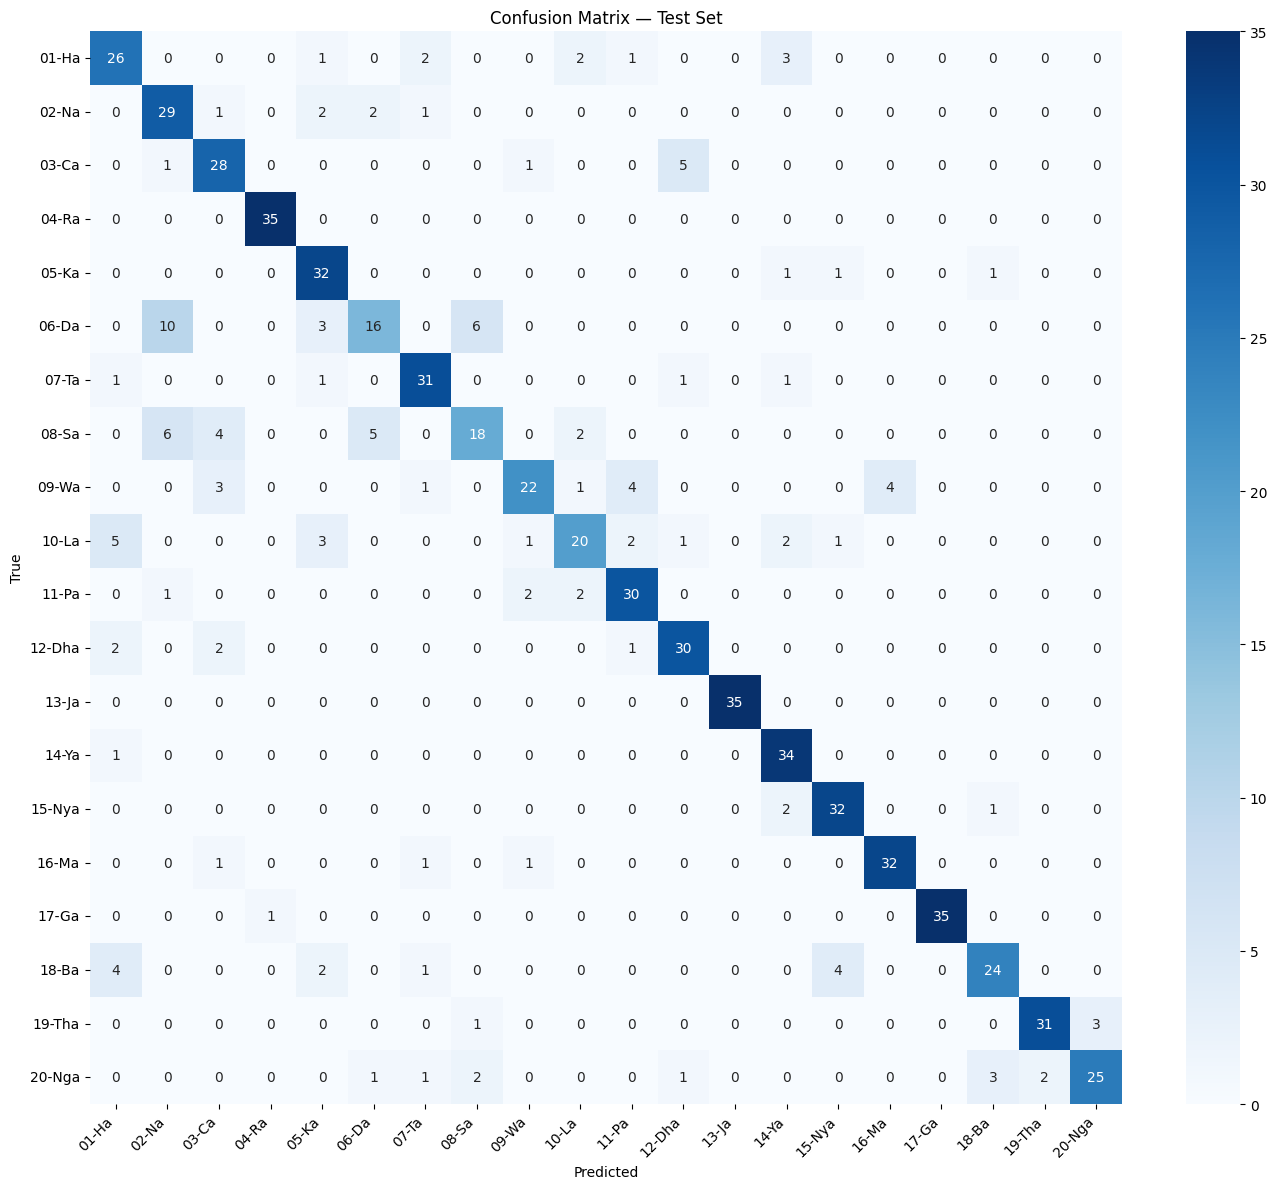


Top 5 kelas dengan error rate tertinggi:
  06-Da: 54.3% salah (19/35)
  08-Sa: 48.6% salah (17/35)
  10-La: 42.9% salah (15/35)
  09-Wa: 37.1% salah (13/35)
  18-Ba: 31.4% salah (11/35)


In [ ]:
# Load model terbaik (yang disimpan ModelCheckpoint)
model = tf.keras.models.load_model(MODEL_PATH)

# Evaluasi di TEST SET — hanya dijalankan sekali di akhir
test_set.reset()
Y_pred    = model.predict(test_set, verbose=1)
y_pred    = np.argmax(Y_pred, axis=1)
y_true    = test_set.classes

# Classification report
print("=" * 60)
print("EVALUASI AKHIR — TEST SET (belum pernah dilihat model)")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

# Analisis kelas dengan error terbanyak
errors_per_class = {}
for i, kelas in enumerate(CLASS_NAMES):
    mask          = y_true == i
    total         = mask.sum()
    salah         = (y_pred[mask] != i).sum()
    errors_per_class[kelas] = {'total': int(total), 'salah': int(salah),
                               'error_rate': round(salah/total*100, 1) if total > 0 else 0}

print("\nTop 5 kelas dengan error rate tertinggi:")
sorted_errors = sorted(errors_per_class.items(), key=lambda x: x[1]['error_rate'], reverse=True)
for kelas, info in sorted_errors[:5]:
    print(f"  {kelas}: {info['error_rate']}% salah ({info['salah']}/{info['total']})")

In [4]:
# export model ke ONNX
import tf2onnx
import onnxruntime as ort
onnx_path = ROOT_DIR / "model_aksara.onnx"

model = tf.keras.models.load_model(MODEL_PATH)
input_signature = [tf.TensorSpec([None, IMG_SIZE, IMG_SIZE, 3], tf.float32, name="input")]
model_proto, _ = tf2onnx.convert.from_keras(model, input_signature, output_path=onnx_path)


I0000 00:00:1780303924.304646   61525 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780303926.722339   61525 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1780303926.722566   61525 single_machine.cc:376] Starting new session
I0000 00:00:1780303926.724537   61525 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780303927.301115   61525 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780303927.404866   61525 devices.cc:67] Nu

In [ ]:
import cv2
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

class OCRPipelineAksara:
    def __init__(self, model_path, class_names, img_size=128, confidence_threshold=0.6):
        self.model = tf.keras.models.load_model(model_path)
        self.class_names = class_names
        self.img_size = img_size
        self.conf_thresh = confidence_threshold

    def binarisasi(self, img_bgr):
        """Ubah foro bgr menjadi biner"""
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        biner = cv2.adaptiveThreshold(
            blur, 255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11,2
        )
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
        biner = cv2.morphologyEx(biner,cv2.MORPH_CLOSE, kernel)
        return biner
    
    def segmentasi_karakter(self, biner):
        """
        Temukan bounding box dengan contour detection
        
        Return: list of (x, y, w, h) dengan urutan kiri->kanan, atas->bawah
        """

        contours, _ = cv2.findContours(
            biner, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        bounding_box = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            
            # filter: abaikan kontour yang terlalu kecil atau terlalu besar
            area = w * h
            if 200 < area < (biner.shape[0] * biner.shape[1] * 0.5):
                bounding_box.append((x, y, w, h))

        # urutkan baris atas dulu (y), lalu kiri ke kanan (x)
        bounding_box.sort(key=lambda b: (b[1] // 40, b[0]))
        return bounding_box
        
    def klasifikasi_satu(self, img_bgr, bbox):
        """Potong satu karater dan prediksi kelasnya"""
        x, y, w, h = bbox

        # padding untuk memperlebar potongan
        pad = 4
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img_bgr.shape[1], x + w + pad)
        y2 = min(img_bgr.shape[0], y + h + pad)
        crop = img_bgr[y1:y2, x1:x2]

        # preprocessing
        resized = cv2.resize(crop, (self.img_size, self.img_size))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        normalized = rgb.astype('float32') / 255.0
        batch = np.expand_dims(normalized, axis=0)

        # prediksi
        probs = self.model.predict(batch, verbose=0)[0]
        pred_idx = np.argmax(probs)
        confidence = float(probs[pred_idx])

        return{
            'kelas': self.class_names[pred_idx],
            'confidence': round(confidence, 3),
            'valid': confidence >= self.conf_thresh,
            'bbox': bbox
        }
    
    def proses(self, image_path, visualisasi=True):
        """
        Jalankan seluruh pipeline OCR pada satu gambar
        
        Return: list hasil prediksi per karakter
        """
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Gambar tidak ditemukan: {image_path}")

        biner = self.binarisasi(img)
        boxes = self.segmentasi_karakter(biner)

        if not boxes:
            print("Tidak ada kaarater yang terdeteksi...")
            self._visualisasi(img, [])
            return []
        
        hasil = [self.klasifikasi_satu(img, box) for box in boxes]

        if visualisasi:
            self._visualisasi(img, hasil)

        # Ringkasan hasil
        valid = [h for h in hasil if h['valid']]
        print(f"\nDitemukan {len(boxes)} karakter | {len(valid)} di atas threshold { (self.conf_thresh)} ")
        print("Prediksi: ", " ".join([h['kelas'] for h in valid]))

        return hasil
    
    def _visualisasi(self, img, hasil):
        """Tampilkan gambar beserta bounding box dan label prediksi"""

        vis = img.copy()
        for h in hasil:
            x, y, w, hh = h['bbox']
            warna = (0, 200, 0) if h['valid'] else (0, 0, 200)
            cv2.rectangle(vis, (x, y), (x+w, y+hh), warna, 2)
            label = f"{h['kelas']} {h['confidence']:.2f}"
            cv2.putText(vis, label, (x, y-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, warna)
            
        plt.figure(figsize=(14, 8))
        plt.axis('off')
        plt.title("Hasil OCR aksara Jawa")
        plt.tight_layout()
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        


In [ ]:
ocr = OCRPipelineAksara(
        model_path=MODEL_PATH,
        class_names= CLASS_NAMES,
        confidence_threshold=0.6
)
img = cv2.imread('images.jpg')
hasil = ocr.proses('images.jpg', visualisasi=True)
                

239